# Clase 1 — Representación de datos de texto

**Módulo de Análisis de Datos de Texto · Notebook 1 de 5**

En esta clase pasamos de un texto crudo a una representación numérica que un algoritmo pueda procesar. Recorreremos:

1. Cargar un corpus en español y trabajar con él en un DataFrame.
2. Tokenización (por palabras y por oraciones).
3. Normalización y eliminación de stopwords.
4. Lematización con spaCy.
5. Stemming con NLTK.
6. Detección de entidades (NER).
7. Bolsa de Palabras y matriz término-documento con `CountVectorizer`.
8. Comprobación empírica de la Ley de Zipf.

> **Ejemplo recurrente.** A lo largo del módulo usaremos el mismo corpus de noticias en español y, para los cálculos a mano, las cinco frases del *corpus de juguete* que ya vimos en clase (`CORPUS_TANGO`).

## 0. Importaciones y descarga de recursos

In [3]:
import re # para el manejo de expresiones regulares
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

import spacy
from sklearn.feature_extraction.text import CountVectorizer

# Recursos NLTK
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)

# Modelo de spaCy en español (descargar si no está instalado)
!python -m spacy download es_core_news_sm
nlp_es = spacy.load('es_core_news_sm')

print('Librerías listas.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 7.3 MB/s eta 0:00:00a 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
Librerías listas.


## 1. El corpus

Trabajaremos con dos corpus:

| Corpus | Tamaño | Uso |
|---|---|---|
| **`CORPUS_TANGO`** | 5 frases | Ejemplos manuales (igual que en las slides) |
| **`CORPUS`** | 40 noticias cortas, 4 categorías | Experimentos con datos reales |

In [4]:
# ── Corpus de juguete ─────────────────────────────────────────────────────────
#Cada frase se considera un documento y este es todo el corpus de tango
CORPUS_TANGO = [
    "El tango es un baile popular",
    "Escuchar tango es placentero",
    "Gardel es un gran valor del tango",
    "Con el tango líquido los sueldos",
    "El tango 01 fue vendido",
]

print('Corpus de juguete (CORPUS_TANGO):')
for i, d in enumerate(CORPUS_TANGO, 1):
    print(f'  D{i}: {d}')

Corpus de juguete (CORPUS_TANGO):
  D1: El tango es un baile popular
  D2: Escuchar tango es placentero
  D3: Gardel es un gran valor del tango
  D4: Con el tango líquido los sueldos
  D5: El tango 01 fue vendido


In [5]:
# ── Corpus de noticias ────────────────────────────────────────────────────────
# 40 documentos cortos en español, 4 temas: tecnología, deportes, política, cultura.
# Está embebido aquí para que el notebook sea autocontenido.

#cada noticia es alrededor de 1 párrafo y equivale cada una a un documento

CORPUS = [
    # --- tecnología ---
    'Una empresa de tecnología presentó un nuevo modelo de inteligencia artificial capaz de generar texto en varios idiomas.',
    'El nuevo procesador promete duplicar la velocidad de los computadores portátiles sin aumentar el consumo de energía.',
    'Los algoritmos de aprendizaje automático están transformando la forma en que las empresas analizan datos masivos.',
    'Un grupo de investigadores publicó un modelo de lenguaje entrenado con miles de millones de palabras en español.',
    'La compañía lanzó una actualización de software que mejora la seguridad y corrige varios errores críticos.',
    'Expertos en ciberseguridad advierten sobre el aumento de ataques con inteligencia artificial generativa.',
    'El nuevo teléfono incorpora una cámara con procesamiento neuronal y reconocimiento de escenas en tiempo real.',
    'Los chips fabricados con tecnología de tres nanómetros llegarán al mercado el próximo año.',
    'Una startup colombiana desarrolló una aplicación que usa modelos de lenguaje para asesoría legal automatizada.',
    'El centro de datos consume menos energía gracias a un sistema de refrigeración basado en agua reciclada.',
    # --- deportes ---
    'El equipo nacional ganó el partido por tres goles a uno en el estadio principal de la capital.',
    'La selección de fútbol clasificó al mundial tras vencer a su rival histórico en tiempo de descuento.',
    'El ciclista colombiano subió al podio en la última etapa de la competencia europea.',
    'Un nuevo récord mundial fue establecido en los cien metros planos durante el campeonato.',
    'El entrenador anunció cambios en la alineación titular para el próximo partido decisivo.',
    'La final del torneo de baloncesto se jugará el sábado entre los dos mejores equipos del país.',
    'El tenista venció en cinco sets a su rival y avanzó a la final del torneo de Grand Slam.',
    'La atleta rompió la marca regional en lanzamiento de jabalina durante los juegos panamericanos.',
    'El nadador colombiano se clasificó a los juegos olímpicos tras una temporada excepcional.',
    'El partido fue suspendido por lluvia y se reanudará mañana en el mismo estadio.',
    # --- política ---
    'El gobierno anunció una nueva reforma tributaria que afectará a las grandes empresas del país.',
    'El congreso aprobó la ley de presupuesto general tras tres jornadas de intenso debate.',
    'La oposición criticó las medidas económicas anunciadas por el ministerio de hacienda esta semana.',
    'El presidente recibió a los líderes regionales para discutir la situación de seguridad en el sur del país.',
    'Las elecciones regionales se celebrarán en octubre con más de cuarenta millones de votantes habilitados.',
    'La corte constitucional declaró inexequible un artículo clave de la última reforma laboral aprobada.',
    'El alcalde presentó el plan de desarrollo con énfasis en movilidad y educación pública.',
    'Un acuerdo de paz entre las facciones políticas permitirá retomar el diálogo sobre la reforma rural.',
    'La ministra de educación defendió ante el congreso el aumento del presupuesto para universidades públicas.',
    'Los partidos políticos comenzaron las negociaciones para definir candidatos a la próxima campaña presidencial.',
    # --- cultura ---
    'La nueva película del director colombiano fue seleccionada para competir en el festival de cine de Cannes.',
    'El museo nacional inauguró una exposición sobre arte precolombino con piezas inéditas del periodo muisca.',
    'Un libro de poesía colombiana ganó el premio internacional de literatura en lengua española este año.',
    'La banda anunció gira mundial con conciertos en quince ciudades de América Latina y Europa.',
    'El festival de cine independiente proyectará más de cien películas durante dos semanas en la capital.',
    'La orquesta sinfónica estrenó una obra del compositor antioqueño con gran acogida del público.',
    'El teatro municipal presenta esta semana una adaptación contemporánea de una obra clásica del siglo de oro.',
    'Una escritora joven publicó su primera novela y ya ha sido traducida a cinco idiomas.',
    'El documental sobre música tradicional del pacífico colombiano fue estrenado en una plataforma de streaming.',
    'La feria del libro recibió más de medio millón de visitantes y cerró con un balance positivo.',
]

LABELS = (['tecnología'] * 10 + ['deportes'] * 10
          + ['política'] * 10 + ['cultura'] * 10)

# Construimos un DataFrame: cada fila es un documento
df = pd.DataFrame({'text': CORPUS, 'category': LABELS})
print(f'Corpus: {len(df)} documentos en {df["category"].nunique()} categorías.')
df.head()

Corpus: 40 documentos en 4 categorías.


,text,category
0,Una empresa de tecnología presentó un nuevo mo...,tecnología
1,El nuevo procesador promete duplicar la veloci...,tecnología
2,Los algoritmos de aprendizaje automático están...,tecnología
3,Un grupo de investigadores publicó un modelo d...,tecnología
4,La compañía lanzó una actualización de softwar...,tecnología


## 2. Tokenización

Tokenizar es partir el texto en unidades mínimas llamadas **tokens** — normalmente palabras.

```
"This is a sample"
    ↓ tokenización ↓
[ "This" ] [ "is" ] [ "a" ] [ "sample" ]
```

Cada variante de tokenización (¿separo signos? ¿números? ¿nombres compuestos?) modifica el espacio de características.

In [7]:
df.head()

,text,category
0,Una empresa de tecnología presentó un nuevo mo...,tecnología
1,El nuevo procesador promete duplicar la veloci...,tecnología
2,Los algoritmos de aprendizaje automático están...,tecnología
3,Un grupo de investigadores publicó un modelo d...,tecnología
4,La compañía lanzó una actualización de softwar...,tecnología


In [18]:
# ── 2a. Tokenización por palabras ─────────────────────────────────────────────

#tokenización de las palabras en minúscula y pues son palabras en español, puede ser necesario
#quitar acentos y puntuaciones que no nos ayudarán. En este caso se separa el texto por palabras
df['tokens'] = df['text'].apply(lambda x: word_tokenize(x.lower(), language='spanish'))
df[['text', 'tokens']].head(3)

,text,tokens
0,Una empresa de tecnología presentó un nuevo mo...,"[una, empresa, de, tecnología, presentó, un, n..."
1,El nuevo procesador promete duplicar la veloci...,"[el, nuevo, procesador, promete, duplicar, la,..."
2,Los algoritmos de aprendizaje automático están...,"[los, algoritmos, de, aprendizaje, automático,..."


In [19]:
# ── 2b. Tokenización por oraciones ────────────────────────────────────────────
# Útil cuando un documento tiene múltiples oraciones. Aunque no es lo usual. 
df['sentences'] = df['text'].apply(lambda x: sent_tokenize(x, language='spanish'))
df[['text', 'sentences']].head(3)

,text,sentences
0,Una empresa de tecnología presentó un nuevo mo...,[Una empresa de tecnología presentó un nuevo m...
1,El nuevo procesador promete duplicar la veloci...,[El nuevo procesador promete duplicar la veloc...
2,Los algoritmos de aprendizaje automático están...,[Los algoritmos de aprendizaje automático está...


In [20]:
# ── 2c. Ejemplo con CountVectorizer (tokenización automática) ─────────────────
# Con valores por defecto CountVectorizer:
#   1. Extrae secuencias de 2+ caracteres alfanuméricos.
#   2. Convierte a minúsculas.
#   3. Construye el lexicón.
#   4. Retorna la matriz dispersa de ocurrencias.

cv_demo = CountVectorizer()
X_demo = cv_demo.fit_transform(['This is is the test 1',
                                 'This is the the the test 2',
                                 'This is the test 3'])

print('Vocabulario:',     cv_demo.get_feature_names_out())
print('Dimensiones X:',   X_demo.shape,  '→ (documentos, palabras)')
print('Matriz completa:\n', X_demo.toarray())
print('Ocurrencias por documento:', X_demo.sum(axis=1).A1)
print('Ocurrencias por token:',     X_demo.sum(axis=0).A1)

Vocabulario: ['is' 'test' 'the' 'this']
Dimensiones X: (3, 4) → (documentos, palabras)
Matriz completa:
 [[2 1 1 1]
 [1 1 3 1]
 [1 1 1 1]]
Ocurrencias por documento: [5 6 4]
Ocurrencias por token: [4 3 5 3]


## 3. Normalización

Normalizar significa llevar los tokens a una forma estándar: minúsculas, sin números, sin signos de puntuación, sin acentos (opcional).

In [21]:
# ── 3a. Minúsculas (ya en tokens, ilustramos sobre el texto crudo) ─────────────
df['tokens_lower'] = df['text'].apply(
    lambda x: [w.lower() for w in word_tokenize(x)]
)
df[['text', 'tokens_lower']].head(2)

,text,tokens_lower
0,Una empresa de tecnología presentó un nuevo mo...,"[una, empresa, de, tecnología, presentó, un, n..."
1,El nuevo procesador promete duplicar la veloci...,"[el, nuevo, procesador, promete, duplicar, la,..."


In [22]:
# ── 3b. Eliminar números y puntuación con expresiones regulares ───────────────
def normalize_text(text):
    text = text.lower()                    # minúsculas
    text = re.sub(r'\d+', '', text)        # quitar números
    text = re.sub(r'[^\w\s]', '', text)    # quitar puntuación
    return text

df['normalized'] = df['text'].apply(normalize_text)
df[['text', 'normalized']].head(3)

,text,normalized
0,Una empresa de tecnología presentó un nuevo mo...,una empresa de tecnología presentó un nuevo mo...
1,El nuevo procesador promete duplicar la veloci...,el nuevo procesador promete duplicar la veloci...
2,Los algoritmos de aprendizaje automático están...,los algoritmos de aprendizaje automático están...


In [ ]:
# ── 3c. Eliminar acentos con CountVectorizer ──────────────────────────────────
cv_accents = CountVectorizer(strip_accents='unicode')
sample = cv_accents.fit_transform(['Hola, ¿cómo estás? Análisis de texto en español.'])
print('Sin acentos:', cv_accents.get_feature_names_out())

Sin acentos: ['analisis' 'como' 'de' 'en' 'espanol' 'estas' 'hola' 'texto']


## 4. Stopwords (palabras vacías)

La **Ley de Zipf** nos dice que muy pocas palabras concentran la mayor parte de las ocurrencias — y esas palabras (artículos, preposiciones, conjunciones) son las menos informativas semánticamente. Las llamamos *stopwords* o palabras vacías.

> ¿Qué tan útiles son "de", "la" o "que" para entender la semántica del texto?

In [ ]:
# ── 4a. Lista de stopwords en español (NLTK) ──────────────────────────────────
#la librería NLTK es la que contiene una lista de las stopwords en español
STOPWORDS_ES = set(stopwords.words('spanish'))
print(f'NLTK tiene {len(STOPWORDS_ES)} stopwords en español.')
print('Algunas:', sorted(STOPWORDS_ES)[:20]) #las primeras 20

NLTK tiene 313 stopwords en español.
Algunas: ['a', 'al', 'algo', 'algunas', 'algunos', 'ante', 'antes', 'como', 'con', 'contra', 'cual', 'cuando', 'de', 'del', 'desde', 'donde', 'durante', 'e', 'el', 'ella']


In [24]:
# ── 4b. Eliminar stopwords de los tokens ──────────────────────────────────────
df['tokens_no_sw'] = df['tokens'].apply(
    #si la palabra no esta en la lista de stopwords que la agregue
    lambda toks: [w for w in toks if w not in STOPWORDS_ES and w.isalpha()]
)

# Antes vs. después
ej = 0
print('Original:  ', df['tokens'].iloc[ej])
print('Sin stops: ', df['tokens_no_sw'].iloc[ej])

Original:   ['una', 'empresa', 'de', 'tecnología', 'presentó', 'un', 'nuevo', 'modelo', 'de', 'inteligencia', 'artificial', 'capaz', 'de', 'generar', 'texto', 'en', 'varios', 'idiomas', '.']
Sin stops:  ['empresa', 'tecnología', 'presentó', 'nuevo', 'modelo', 'inteligencia', 'artificial', 'capaz', 'generar', 'texto', 'varios', 'idiomas']


In [ ]:
# ── 4c. Stopwords directamente en CountVectorizer ─────────────────────────────
SW_LIST = sorted(STOPWORDS_ES)  # CountVectorizer espera lista, no set

cv_sw = CountVectorizer(stop_words=SW_LIST, lowercase=True)
X_sw  = cv_sw.fit_transform(CORPUS_TANGO)

df_tango = pd.DataFrame(
    X_sw.toarray(),
    columns=cv_sw.get_feature_names_out(),
    index=[f'D{i+1}' for i in range(len(CORPUS_TANGO))]
)
print('Matriz término-documento — corpus de juguete:')
df_tango
#por ejemplo acá hay un caso particular, y es que los números no se quitaron
# entonces parece que hacen parte del lexicon 

Matriz término-documento — corpus de juguete:


,01,baile,escuchar,gardel,gran,líquido,placentero,popular,sueldos,tango,valor,vendido
D1,0,1,0,0,0,0,0,1,0,1,0,0
D2,0,0,1,0,0,0,1,0,0,1,0,0
D3,0,0,0,1,1,0,0,0,0,1,1,0
D4,0,0,0,0,0,1,0,0,1,1,0,0
D5,1,0,0,0,0,0,0,0,0,1,0,1


## 5. Lematización

La **lematización** usa información gramatical para reducir cada palabra a su **lema** (forma canónica válida en el idioma).

| Forma | Lema |
|---|---|
| corriendo | correr |
| bailarines | bailarín |
| danzas | danzar |

Usaremos **spaCy** con el modelo `es_core_news_sm`.

In [26]:
# ── 5a. Función de lematización ───────────────────────────────────────────────
def lemmatize_es(tokens):
    """
    Recibe una lista de tokens (ya sin stopwords) y devuelve sus lemas.
    """
    doc = nlp_es(' '.join(tokens))
    return [token.lemma_ for token in doc]

df['lemmas'] = df['tokens_no_sw'].apply(lemmatize_es)

print('Tokens sin stop: ', df['tokens_no_sw'].iloc[0])
print('Lemas:           ', df['lemmas'].iloc[0])

Tokens sin stop:  ['empresa', 'tecnología', 'presentó', 'nuevo', 'modelo', 'inteligencia', 'artificial', 'capaz', 'generar', 'texto', 'varios', 'idiomas']
Lemas:            ['empresa', 'tecnologío', 'presentar', 'nuevo', 'modelo', 'inteligencia', 'artificial', 'capaz', 'generar', 'texto', 'varios', 'idioma']


In [27]:
# ── 5b. Comparación token → lema en el corpus completo ────────────────────────
df[['text', 'tokens_no_sw', 'lemmas']].head(4)

,text,tokens_no_sw,lemmas
0,Una empresa de tecnología presentó un nuevo mo...,"[empresa, tecnología, presentó, nuevo, modelo,...","[empresa, tecnologío, presentar, nuevo, modelo..."
1,El nuevo procesador promete duplicar la veloci...,"[nuevo, procesador, promete, duplicar, velocid...","[nuevo, procesador, prometer, duplicar, veloci..."
2,Los algoritmos de aprendizaje automático están...,"[algoritmos, aprendizaje, automático, transfor...","[algoritmo, aprendizaje, automático, transform..."
3,Un grupo de investigadores publicó un modelo d...,"[grupo, investigadores, publicó, modelo, lengu...","[grupo, investigador, publicar, modelo, lengua..."


## 6. Stemming

El **stemming** recorta la palabra a una raíz heurística. Más rápido que la lematización, pero la raíz puede **no ser** una palabra válida.

| Forma | Stemming | Lematización |
|---|---|---|
| corriendo | `corr` | correr |
| bailarines | `bail` | bailarín |

Ambas técnicas **reducen la dimensionalidad**: agrupan palabras de la misma familia bajo un único término.

In [ ]:
# ── 6a. Comparación de raíces para palabras de ejemplo ────────────────────────
stemmer = SnowballStemmer('spanish')

palabras = ['baile', 'bailes', 'bailarines', 'bailando',
            'corriendo', 'correr', 'corrida',
            'danza', 'danzas', 'danzar']

print(f'  {"Palabra":<15}  {"Stem"}')
print('  ' + '-'*25)
for p in palabras:
    print(f'  {p:<15}  {stemmer.stem(p)}')

  Palabra          Stem
  -------------------------
  baile            bail
  bailes           bail
  bailarines       bailarin
  bailando         bail
  corriendo        corr
  correr           corr
  corrida          corr
  danza            danz
  danzas           danz
  danzar           danz


In [ ]:
# ── 6b. Aplicar stemming al corpus de noticias ────────────────────────────────
df['stems'] = df['tokens_no_sw'].apply(
    lambda toks: [stemmer.stem(w) for w in toks]
)

# Tabla comparativa para un documento
ej = 2
pd.DataFrame({
    'token':  df['tokens_no_sw'].iloc[ej],
    'lema':   df['lemmas'].iloc[ej],
    'stem':   df['stems'].iloc[ej]
})

,token,lema,stem
0,algoritmos,algoritmo,algoritm
1,aprendizaje,aprendizaje,aprendizaj
2,automático,automático,automat
3,transformando,transformar,transform
4,forma,forma,form
5,empresas,empresa,empres
6,analizan,analizar,analiz
7,datos,dato,dat
8,masivos,masivo,masiv


## 7. Detección de entidades (NER)

El **Reconocimiento de Entidades Nombradas** (*Named Entity Recognition*, NER) identifica y clasifica expresiones que refieren a **personas, organizaciones, lugares, fechas, cantidades**, etc.

Aplicaciones: análisis de sentimiento sobre marcas, sistemas de recomendación, extracción de información para bases de conocimiento.

In [ ]:
# ── 7a. Ejemplo rápido con el párrafo del tango ───────────────────────────────
parrafo_tango = (
    'El tango revolucionó el baile popular introduciendo una danza sensual '
    'con pareja abrazada. Enrique Santos Discépolo, uno de sus máximos poetas, '
    'nació en Buenos Aires y definió al tango como un pensamiento triste que se baila.'
)

doc = nlp_es(parrafo_tango)
print('Entidades encontradas:')
for ent in doc.ents:
    print(f'  [{ent.label_:8s}]  {ent.text}')

Entidades encontradas:
  [PER     ]  Enrique Santos Discépolo
  [LOC     ]  Buenos Aires


In [ ]:
# ── 7b. Aplicar NER al corpus de noticias ─────────────────────────────────────
def identify_entities_es(text):
    doc = nlp_es(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

df['entities'] = df['text'].apply(identify_entities_es)
df[['text', 'entities']].head(6)

,text,entities
0,Una empresa de tecnología presentó un nuevo mo...,[]
1,El nuevo procesador promete duplicar la veloci...,[]
2,Los algoritmos de aprendizaje automático están...,[]
3,Un grupo de investigadores publicó un modelo d...,[]
4,La compañía lanzó una actualización de softwar...,[]
5,Expertos en ciberseguridad advierten sobre el ...,[]


## 8. Bolsa de Palabras y matriz término-documento

La **Bolsa de Palabras** (*Bag of Words*, BoW) es la representación numérica fundamental del texto:
- El **orden** de las palabras no importa; solo cuenta cuántas veces aparece cada una.
- Cada término se convierte en una **dimensión** (característica / feature).
- El resultado es una **matriz término-documento**: filas = documentos, columnas = términos.

Esta matriz es dispersa (*sparse*): la mayoría de las celdas son cero.

In [ ]:
# ── 8a. BoW sobre el corpus de juguete ────────────────────────────────────────
# (ya la vimos en la sección 4c; aquí mostramos el vector de un documento)
print('Vector del documento D1 (tango es un baile popular):')
print(df_tango.loc['D1'])

Vector del documento D1 (tango es un baile popular):
01            0
baile         1
escuchar      0
gardel        0
gran          0
líquido       0
placentero    0
popular       1
sueldos       0
tango         1
valor         0
vendido       0
Name: D1, dtype: int64


In [ ]:
# ── 8b. BoW sobre el corpus de noticias ───────────────────────────────────────
cv_news = CountVectorizer(stop_words=SW_LIST, lowercase=True, min_df=2)
X_news  = cv_news.fit_transform(CORPUS)

print(f'Matriz término-documento del corpus de noticias: {X_news.shape}')
print(f'  {X_news.shape[0]} documentos  ×  {X_news.shape[1]} términos')
nnz = X_news.nnz
total = X_news.shape[0] * X_news.shape[1]
print(f'Densidad: {nnz/total:.2%} de celdas no son cero  →  representación MUY dispersa')

Matriz término-documento del corpus de noticias: (40, 52)
  40 documentos  ×  52 términos
Densidad: 5.53% de celdas no son cero  →  representación MUY dispersa


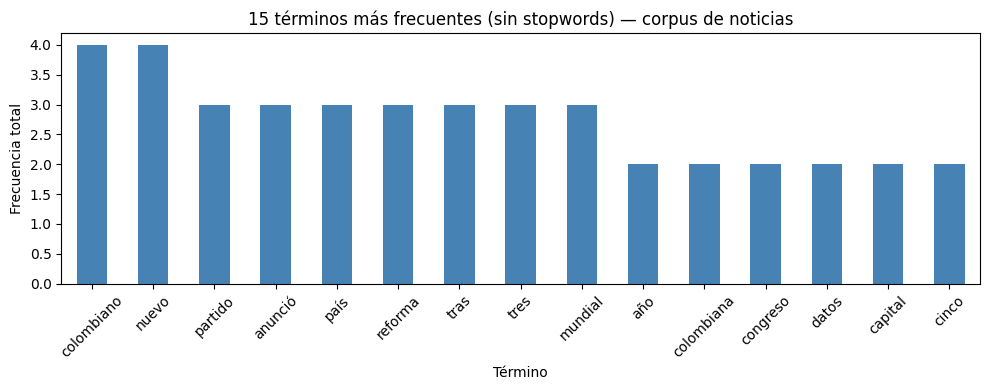

In [ ]:
# ── 8c. Palabras más frecuentes (sin stopwords) ───────────────────────────────
df_news_bow = pd.DataFrame(
    X_news.toarray(),
    columns=cv_news.get_feature_names_out()
)
word_freq = df_news_bow.sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
word_freq.head(15).plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('15 términos más frecuentes (sin stopwords) — corpus de noticias')
ax.set_xlabel('Término')
ax.set_ylabel('Frecuencia total')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 9. La Ley de Zipf, en nuestros datos

La **Ley de Zipf** establece que la frecuencia de un término es **inversamente proporcional a su rango**. Unas pocas palabras ("de", "la", "que") dominan la frecuencia total... y son las menos informativas.

En escala log-log, esta relación produce una **línea recta** — lo verificaremos empíricamente.

In [ ]:
# ── 9a. Frecuencias incluyendo stopwords (curva clásica de Zipf) ──────────────
cv_zipf = CountVectorizer(lowercase=True)
X_zipf  = cv_zipf.fit_transform(CORPUS)

frec         = np.asarray(X_zipf.sum(axis=0)).ravel()
orden        = np.argsort(-frec)
frec_ord     = frec[orden]
vocab        = np.array(cv_zipf.get_feature_names_out())

print('Top 10 términos más frecuentes (con stopwords):')
for t, f in zip(vocab[orden][:10], frec_ord[:10]):
    print(f'  {t:<15} {f}')

Top 10 términos más frecuentes (con stopwords):
  de              46
  el              34
  la              26
  en              22
  del             13
  una             13
  con             10
  los             9
  un              9
  para            6


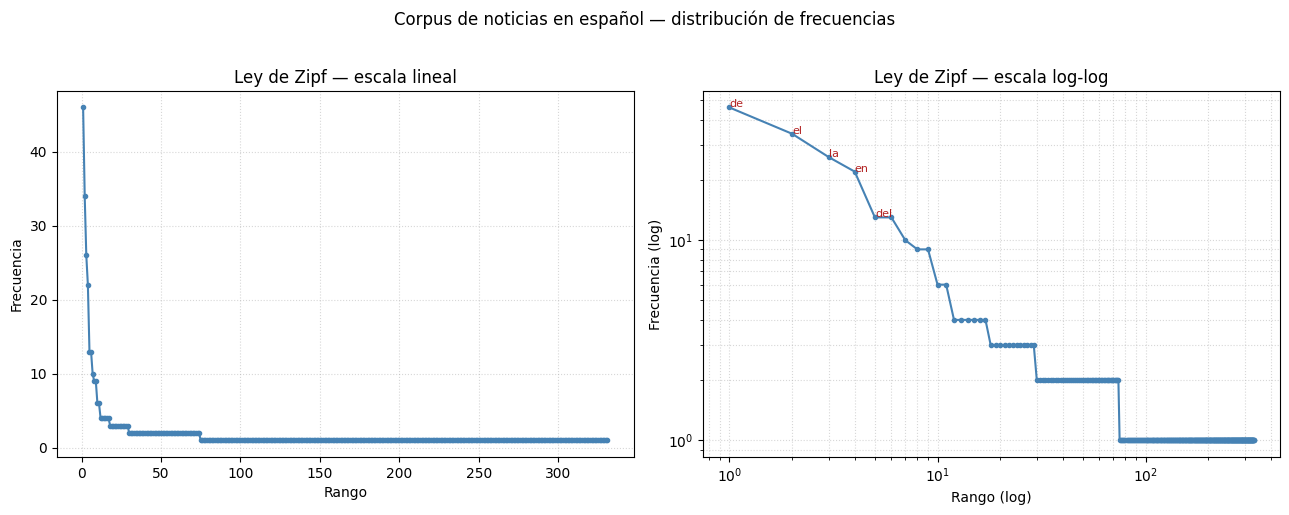


En escala log-log la curva se aproxima a una recta: evidencia de la Ley de Zipf.
Las palabras de la "cabeza" (stopwords) dominan la masa total — motivación para TF-IDF.


In [ ]:
# ── 9b. Gráfico log-log (comprobación empírica) ───────────────────────────────
rangos = np.arange(1, len(frec_ord) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Escala lineal
axes[0].plot(rangos, frec_ord, marker='.', linestyle='-', color='steelblue')
axes[0].set_xlabel('Rango')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Ley de Zipf — escala lineal')
axes[0].grid(True, linestyle=':', alpha=0.5)

# Escala log-log
axes[1].loglog(rangos, frec_ord, marker='.', linestyle='-', color='steelblue')
axes[1].set_xlabel('Rango (log)')
axes[1].set_ylabel('Frecuencia (log)')
axes[1].set_title('Ley de Zipf — escala log-log')
axes[1].grid(True, which='both', linestyle=':', alpha=0.5)

# Anotar las 5 palabras más frecuentes
for i in range(5):
    axes[1].annotate(vocab[orden[i]], xy=(rangos[i], frec_ord[i]),
                     fontsize=8, color='firebrick')

plt.suptitle('Corpus de noticias en español — distribución de frecuencias', y=1.02)
plt.tight_layout()
plt.show()

print('\nEn escala log-log la curva se aproxima a una recta: evidencia de la Ley de Zipf.')
print('Las palabras de la "cabeza" (stopwords) dominan la masa total — motivación para TF-IDF.')

## 10. Ejercicios

Completa el código donde diga `# TODO`. Son ejercicios cortos para afianzar lo visto.

In [ ]:
# Ejercicio 1
# Tokeniza y normaliza los documentos del corpus de noticias eliminando stopwords.
# Imprime los 5 tokens más frecuentes del documento 0 (primera noticia de tecnología).

# TODO:

In [ ]:
# Ejercicio 2
# Compara stemming y lematización en el primer documento del corpus.
# ¿Cuántos tokens únicos hay en cada representación? ¿Cuál reduce más la dimensionalidad?

# TODO:

In [ ]:
# Ejercicio 3
# Construye la matriz término-documento del corpus de noticias
# SIN quitar stopwords. Compara el tamaño del vocabulario con la versión
# que sí las quita (sección 8b). ¿Cuántos términos adicionales hay?

# TODO:

In [ ]:
# Ejercicio 4
# Usa el modelo de spaCy para extraer todas las entidades del corpus de noticias.
# ¿Cuáles son las 5 entidades (texto) más mencionadas? ¿De qué tipo son?

# TODO:

## Lo que sigue

Convertimos texto en una matriz de frecuencias, pero `"de"` aparece más que `"tango"`. La frecuencia cruda **no mide importancia**.

**Próxima clase:** TF-IDF y similitud coseno — cómo pesar las palabras y comparar documentos.